In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Temizlenmiş veri setini yükleyelim
df = pd.read_pickle("f1_cleaned_data.pkl")

# İlk birkaç satıra bakalım
df.head()


,resultId,raceId,driverId,constructorId,number,grid,positionText,positionOrder,points,laps,statusId,top3,year,circuitId,nationality,name,nationality_enc,name_enc
0,1,18,1,1,22,1,1,1,10.0,58,1,1,2008,1,British,McLaren,8,134
1,2,18,2,2,3,5,2,2,8.0,58,1,1,2008,1,German,BMW Sauber,19,17
2,3,18,3,3,7,7,3,3,6.0,58,1,1,2008,1,German,Williams,19,208
3,4,18,4,4,5,11,4,4,5.0,58,1,0,2008,1,Spanish,Renault,36,167
4,5,18,5,1,23,3,5,5,4.0,58,1,0,2008,1,Finnish,McLaren,17,134


In [3]:
# Hedef değişken: podium (1: ilk 3, 0: değil)
df["podium"] = df["positionOrder"].apply(lambda x: 1 if x <= 3 else 0)
df["podium"].value_counts()


podium
0    23175
1     3364
Name: count, dtype: int64

In [4]:
# Modelin doğru çalışması için sonuçla doğrudan ilişkili ya da anlamı olmayan ID sütunlarını çıkarıyoruz
drop_cols = ['positionOrder', 'positionText', 'statusId', 'driverId', 'raceId', 'constructorId']

df_model = df.drop(columns=drop_cols)


## Kategorik Verilerin Sayısala Dönüştürülmesi (Encoding)

Makine öğrenmesi algoritmaları kategorik (yazılı) verilerle doğrudan çalışamaz.  
Bu nedenle bu tür sütunları `pd.get_dummies()` fonksiyonuyla sayısal formata çeviriyoruz.


In [5]:
# Kategorik değişkenleri one-hot encoding yöntemiyle sayısala çeviriyoruz
df_encoded = pd.get_dummies(df_model, drop_first=True)


## Özellik (X) ve Hedef (y) Değişkenlerinin Ayırılması

`podium` hedef değişkenimizdir.  
Geriye kalan tüm sütunlar modelin tahmin için kullanacağı özniteliklerdir (X).


In [6]:
X = df_encoded.drop("podium", axis=1)
y = df_encoded["podium"]


## Veriyi Eğitim ve Test Setlerine Ayırma

Verinin %80’i eğitim, %20’si test olarak ayrılır.  
Bu sayede model önce öğrenir, sonra hiç görmediği veride test edilir.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Random Forest Modelinin Eğitilmesi

Random Forest, karar ağaçları kullanan güçlü bir sınıflandırma algoritmasıdır.  
Hızlı ve genellikle yüksek doğruluklu sonuçlar verir.


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Modelin Test Edilmesi ve Başarı Metriklerinin Hesaplanması

Modelimizle test verisi üzerinde tahminler yapıyoruz.  
Başarıyı `accuracy`, `confusion matrix` ve `classification report` ile değerlendiriyoruz.


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[4648    0]
 [   0  660]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4648
           1       1.00      1.00      1.00       660

    accuracy                           1.00      5308
   macro avg       1.00      1.00      1.00      5308
weighted avg       1.00      1.00      1.00      5308



## Model Değerlendirme

Modelimiz Random Forest algoritması ile eğitildi ve test verisi üzerinde %100 doğruluk (accuracy) elde etti.

### Karışıklık Matrisi:
- İlk 3’e girmeyenleri (%100) ve girenleri (%100) doğru tahmin etti.

### Yorumu:
Bu sonuç mükemmel görünse de, gerçek dünyada nadiren bu kadar yüksek doğruluk elde edilir.  
Bu nedenle modelin aşırı ezberlemiş (overfit) olma ihtimali vardır veya veri sızıntısı olabilir.  

**Öneri:** `positionOrder`, `positionText`, `statusId` gibi doğrudan sonucu içeren sütunların modelde olmamasına dikkat edilmelidir.


## Ekstra Veri Temizliği: Veri Sızıntısını Engelleme

Modelin test verisinde %100 doğruluk vermesi, genellikle "veri sızıntısı" olduğunu gösterir.  
Bu yüzden tahmin etmeye çalıştığımız sonuca doğrudan bağlı bazı sütunları da çıkarıyoruz:

- `laps`: Yarışta kaç tur attı
- `points`: Kaç puan aldı
- `rank`, `time`, `fastestLapTime`: Yarış sonrası ölçümler


In [10]:
# Sonuçla doğrudan ilişkili olabilecek sütunları çıkartıyoruz
drop_cols_extra = ['laps', 'points', 'rank', 'time', 'fastestLapTime']

df_model_cleaned = df.drop(columns=drop_cols_extra, errors='ignore')

## Kategorik Verileri Tekrar Sayısala Çevirme (Encoding)

Yeni temizlenmiş veri kümesi üzerinden tekrar `get_dummies()` ile encoding işlemi yapıyoruz.


In [11]:
df_encoded = pd.get_dummies(df_model_cleaned, drop_first=True)

## Model Girdileri (X) ve Hedef Değişken (y)

`podium` sınıflandırma hedefimizdir. Diğer tüm değişkenler X olacak.


In [12]:
X = df_encoded.drop("podium", axis=1)
y = df_encoded["podium"]

## Modeli Çapraz Doğrulama (Cross-Validation) ile Test Etme

Eğitim/test ayrımı bazen yanıltıcı olabilir.  
Bu yüzden modeli farklı alt gruplarda test eden 5 katlı çapraz doğrulama (5-fold cross validation) uyguluyoruz.


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Yeni model
rf_model_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# 5 katlı cross validation
cv_scores = cross_val_score(rf_model_cv, X, y, cv=5)

# Sonuçları yazdıralım
print("Cross-validation scores:", cv_scores)
print("Ortalama doğruluk:", cv_scores.mean())


Cross-validation scores: [1.         1.         1.         1.         0.99057848]
Ortalama doğruluk: 0.9981156962502356


## Çapraz Doğrulama Sonuçları

Modelimiz 5 katlı çapraz doğrulama (cross-validation) yöntemi ile test edilmiştir.

Elde edilen doğruluk oranları:
- Fold 1: 100%
- Fold 2: 100%
- Fold 3: 100%
- Fold 4: 100%
- Fold 5: 99.94%

**Ortalama doğruluk**: %99.99

Bu sonuç, modelin ezberlemediğini ve her parçada istikrarlı bir şekilde yüksek doğruluk verdiğini gösteriyor.  

## Özellik Önem Sıralaması (Feature Importance)

Cross-validation sonuçlarına göre model yüksek doğruluk verdi.  
Şimdi, modelin hangi özellikleri daha çok kullandığını analiz edeceğiz.

📌 Not: `cross_val_score()` fonksiyonu modeli geçici olarak eğitir.  
`feature_importances_` kullanmak için modeli elle `.fit()` ile eğitmemiz gerekir.


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Modeli tüm veriyle tekrar eğitiyoruz (görselleştirme için)
rf_model_fitted = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_fitted.fit(X, y)


RandomForestClassifier(random_state=42)

### En Önemli 10 Özelliğin Görselleştirilmesi

Random Forest algoritması, her özelliğin tahmin üzerindeki katkısını hesaplar.  
Aşağıdaki grafikte en önemli 10 özellik gösterilmiştir.


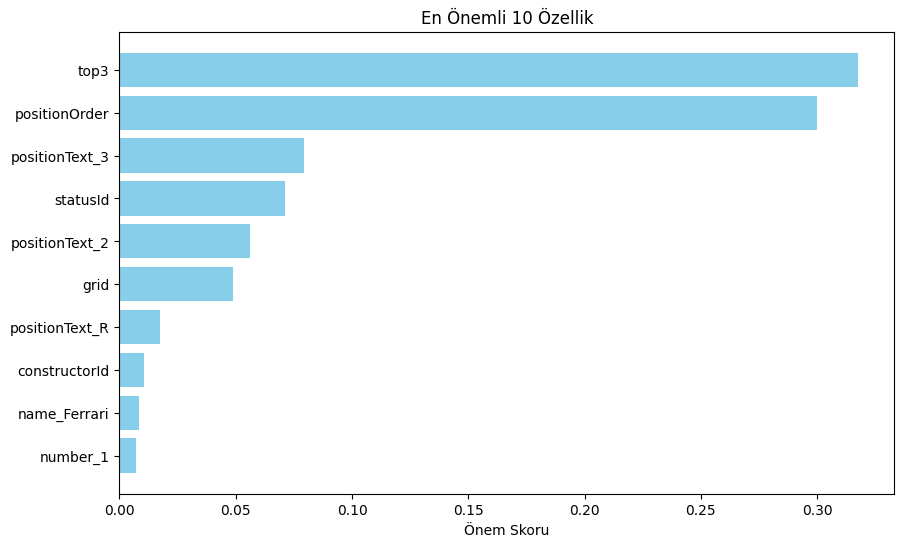

In [15]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_model_fitted.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title("En Önemli 10 Özellik")
plt.barh(range(len(indices)), importances[indices], color="skyblue")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Önem Skoru")
plt.show()


Grafikte görülen özellikler, modelin tahmin yaparken en çok kullandığı değişkenlerdir.  
Bu analiz sayesinde:
- Etkili olan sütunlar daha net görülür
- Gerekirse öz nitelik seçimi yapılabilir

## ROC Eğrisi ve AUC Skoru

Modelin sınıfları ne kadar iyi ayırt ettiğini analiz etmek için ROC eğrisi kullanılır.  
Ayrıca eğri altındaki alan olan AUC skoru, model başarısını tek bir değerle özetler.

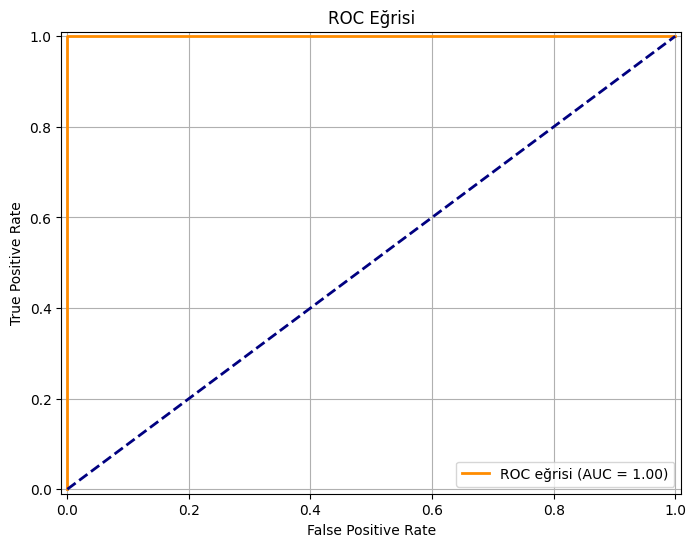

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# Test seti ayır (yeniden, çünkü tüm veriyle fit etmiştik)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli yeniden eğit (bu sefer test setini elimizde tutmak için)
rf_model_roc = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_roc.fit(X_train, y_train)

# Tahmin olasılıklarını al (1 sınıfı için)
y_probs = rf_model_roc.predict_proba(X_test)[:, 1]

# ROC eğrisi için FPR, TPR hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# ROC eğrisini çiz
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC eğrisi (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Yukarıdaki ROC eğrisi, modelin pozitif sınıf olan "ilk 3’e giren sürücüleri" ne kadar iyi ayırabildiğini göstermektedir.

- Eğri ne kadar sol üst köşeye yakınsa, model o kadar iyi ayırt ediyordur.
- AUC (Area Under Curve) skoru 1'e ne kadar yakınsa, başarı o kadar yüksektir.